# SIADS 696 - Milestone II

## Supervised Learning

### Import the required modules


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

pd.set_option('display.float_format', lambda x: '%.3f' % x)

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import  Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, 
)
from sklearn.inspection import permutation_importance
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import (
    GridSearchCV, HalvingGridSearchCV, RandomizedSearchCV,
    cross_val_score, KFold, learning_curve
)



### Import Train/Test Data from Pipeline


In [2]:
# Import the data
BIN = Path('bin')
X_train = pd.read_csv(BIN / 'X_train.csv')
y_train = pd.read_csv(BIN / 'y_train.csv')
X_test  = pd.read_csv(BIN / 'X_test.csv')
y_test  = pd.read_csv(BIN / 'y_test.csv')


# Use a subset of the data when building and testing models
USE_SUBSET   = True        
SUBSET_FRAC  = 0.001        
SEED         = 42

if USE_SUBSET:
    def _sub(df): return df.sample(frac=SUBSET_FRAC, random_state=SEED).reset_index(drop=True)
    X_train, y_train = _sub(X_train), _sub(y_train)
    X_test , y_test  = _sub(X_test) , _sub(y_test)

print(f"{X_train.shape[0]:,} train rows  |  {X_test.shape[0]:,} test rows")


# Set and flatten targert variable
target_variable = 'Beta_winsorized'
y_train = y_train[target_variable].values.ravel()
y_test  = y_test[target_variable].values.ravel()

print(pd.Series(y_train, name=target_variable).head())

40 train rows  |  10 test rows
0   2.797
1   0.934
2   0.946
3   1.322
4   0.763
Name: Beta_winsorized, dtype: float64


### Import the metadata 

In [3]:
# Variable labels (short human-readable descriptions)
with open('variable_labels.yaml') as f:
    variable_labels_dict = yaml.safe_load(f)

# SAS format for each original variable (tells you if cat / numeric)
with open('variable_formats.yaml') as f:
    variable_formats_dict = yaml.safe_load(f)

# Mapping from format-name → {category-code: category-text}
with open('categorical_variables_categories.yaml') as f:
    categorical_variables_categories_dict = yaml.safe_load(f)

# List of all one-hot (dummy) columns produced during cleaning
with open('cleaned_variables.yaml') as f:
    cleaned_vars = yaml.safe_load(f)
new_categorical_variables = set(cleaned_vars['categorical_variables'])

### Model Selection and Justification

We chose these models based on the following criteria:

1. Fulfill the assignment requirements
2. *More writing to come*


## Model Creation

### Function to tune and evaluate models

In [ ]:
def tune_and_evaluate(model_cls, param_grid, *,
                      X_train, y_train, X_test, y_test,
                      label='', search_strategy='grid',
                      cv_splits=5, random_state=42, n_iter=10, factor=3,
                      metric='neg_root_mean_squared_error'):

    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    if issubclass(model_cls, KNeighborsRegressor):
        base = Pipeline([('scale', StandardScaler()),
                         ('knn', model_cls())])
        param_grid = {('knn__' + k if not k.startswith('knn__') else k): v
                      for k, v in param_grid.items()}
    else:
        kwargs = {'random_state': random_state} if 'random_state' in model_cls().get_params() else {}
        base = model_cls(**kwargs)

    strategy_map = {
        'grid'   : (GridSearchCV,       {'param_grid': param_grid}),
        'random' : (RandomizedSearchCV, {'param_distributions': param_grid,
                                         'n_iter': n_iter, 'random_state': random_state}),
        'halving': (HalvingGridSearchCV,{'param_grid': param_grid, 'factor': factor,
                                         'random_state': random_state})
    }
    SearchCV, extra_kw = strategy_map[search_strategy]
    search = SearchCV(estimator=base, scoring=metric, cv=cv,
                      n_jobs=-1, verbose=0, **extra_kw).fit(X_train, y_train)

    best = search.best_estimator_
    y_pred = best.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))    

    cv_mean = -search.cv_results_['mean_test_score'][search.best_index_]
    cv_std  =  search.cv_results_['std_test_score'][search.best_index_]

    return best, {'model': f'{label or model_cls.__name__} (tuned – {search_strategy})',
                  'MAE': mae,
                  'RMSE': rmse,
                  'CV_RMSE_mean': cv_mean,
                  'CV_RMSE_sd': cv_std,
                  'best_params': search.best_params_}

### Set the Hyper-parameter grids

In [5]:
gb_grid   = {'learning_rate':[.02,.03,.04], 'max_depth':[10,15,20],
             'max_iter':[400,800], 'l2_regularization':[0,.0005,.001],
             'min_samples_leaf':[10,20], 'max_leaf_nodes':[31,63]}

lasso_grid= {'alpha':np.logspace(-4,-1,7), 'max_iter':[5000]}

def _max_k():          
    return min(15, max(3, (len(X_train) // 5) - 1))

knn_grid  = {'n_neighbors': list(range(3, _max_k()+1, 2)),
             'weights':['uniform','distance'], 'p':[1,2]}



### Train the Models

In [6]:
results, best_models = [], {}
for lab, cls, grid, strat in [
    ('GB',    HistGradientBoostingRegressor, gb_grid,   'halving'),
    ('Lasso', Lasso,                        lasso_grid, 'grid'),
    ('k‑NN',  KNeighborsRegressor,          knn_grid,   'grid')]:
    best, res = tune_and_evaluate(cls, grid, X_train=X_train, y_train=y_train,
                                  X_test=X_test, y_test=y_test,
                                  label=lab, search_strategy=strat)
    best_models[lab] = best
    results.append(res)
    print(f"{res['model']}: MAE {res['MAE']:.4f} | RMSE {res['RMSE']:.4f} "
          f"| CV {res['CV_RMSE_mean']:.4f} ± {res['CV_RMSE_sd']:.4f}")

results_df = (pd.DataFrame(results)
              .set_index('model')
              .sort_values('CV_RMSE_mean'))
display(results_df.style.format({'MAE':'{:.4f}','RMSE':'{:.4f}',
                                 'CV_RMSE_mean':'{:.4f}','CV_RMSE_sd':'{:.4f}'}))

GB (tuned – halving): MAE 0.5938 | RMSE 0.7684 | CV 0.4713 ± 0.3042
Lasso (tuned – grid): MAE 0.5630 | RMSE 0.8133 | CV 0.7391 ± 0.2208


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.963e-03, tolerance: 1.404e-03
  model = cd_fast.enet_coordinate_descent(
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.354e-03, tolerance: 1.568e-03
  model = cd_fast.enet_coordinate_descent(
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the featu

k‑NN (tuned – grid): MAE 0.6482 | RMSE 0.8673 | CV 0.7629 ± 0.2154


,MAE,RMSE,CV_RMSE_mean,CV_RMSE_sd,best_params
model,,,,,
GB (tuned – halving),0.5938,0.7684,0.4713,0.3042,"{'l2_regularization': 0, 'learning_rate': 0.02, 'max_depth': 15, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}"
Lasso (tuned – grid),0.5630,0.8133,0.7391,0.2208,"{'alpha': np.float64(0.1), 'max_iter': 5000}"
k‑NN (tuned – grid),0.6482,0.8673,0.7629,0.2154,"{'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}"


### Learning Curve

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
 

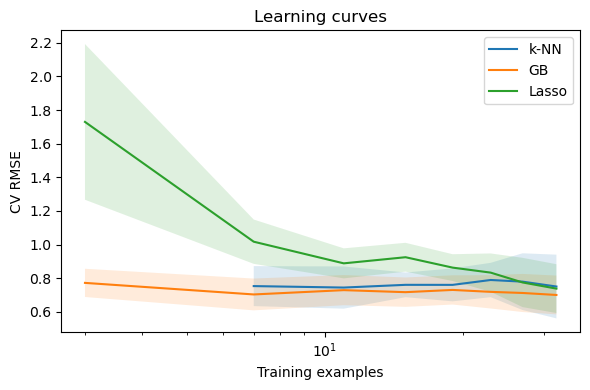

In [7]:
def safe_learning_curve(model, X, y, cv_splits=5, train_sizes=np.linspace(0.1,1.0,8)):
    cv = min(cv_splits, max(2, len(X)//2))

    if isinstance(model, Pipeline) and 'knn' in dict(model.named_steps):
        k = model.named_steps['knn'].n_neighbors
        if k >= len(X):                      
            model = clone(model)
            model.named_steps['knn'].n_neighbors = len(X)-1
    s, train_scores, val_scores = learning_curve(model, X, y,
                                                 cv=cv,
                                                 train_sizes=train_sizes,
                                                 scoring='neg_root_mean_squared_error',
                                                 n_jobs=-1)
    return s, -val_scores.mean(axis=1), val_scores.std(axis=1)

curves = {}
for name, mdl in [('k‑NN', best_models['k‑NN']),
                  ('GB' , best_models['GB' ]),
                  ('Lasso', best_models['Lasso'])]:
    s, m, sd = safe_learning_curve(mdl, X_train, y_train)
    curves[name] = (s, m, sd)


# Plot learning curves
plt.figure(figsize=(6,4))
for name,(s,m,sd) in curves.items():
    plt.plot(s, m, label=name)
    plt.fill_between(s, m-sd, m+sd, alpha=0.15)
plt.xscale('log'); plt.xlabel('Training examples'); plt.ylabel('CV RMSE')
plt.title('Learning curves'); plt.legend(); plt.tight_layout()

## Analysis of Most Performant  Models

In [ ]:
# Set the best model
best_model = best_models['GB']


### Feature Importance and Ablation

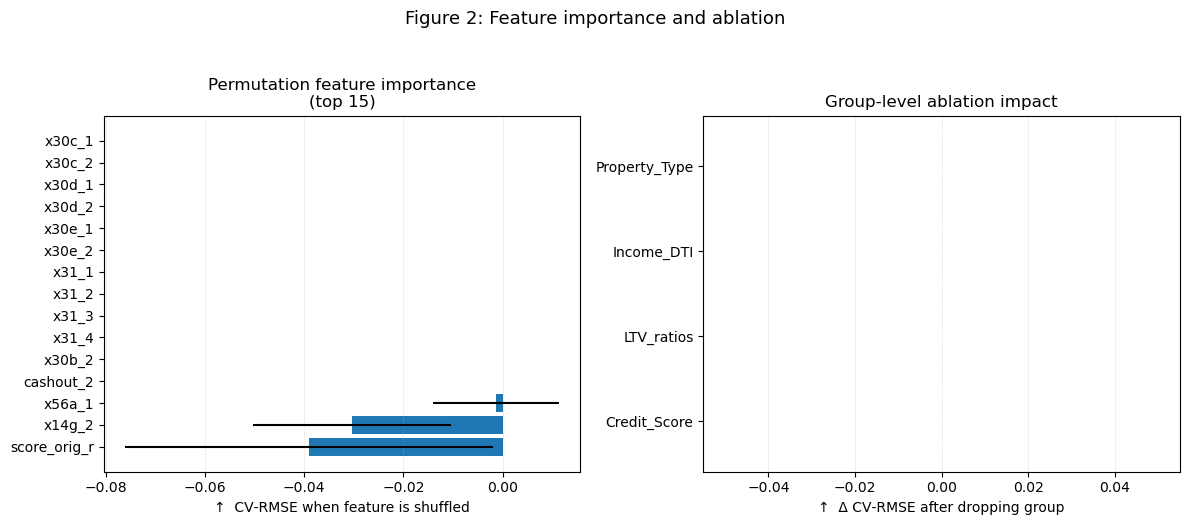

In [11]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='neg_root_mean_squared_error'
)
# Get top‑15 features
idx_sorted = perm.importances_mean.argsort()[::-1][:15]
top_feats  = X_test.columns[idx_sorted]
imp_mean   = perm.importances_mean[idx_sorted] * -1   # convert to +RMSE  (bigger = worse)
imp_sd     = perm.importances_std[idx_sorted]


# Define the featured groups 
groups = {
    'Credit_Score'  : [c for c in X_train.columns if 'credit' in c.lower()],
    'LTV_ratios'    : [c for c in X_train.columns if 'ltv'    in c.lower()],
    'Income_DTI'    : [c for c in X_train.columns if 'dti'    in c.lower()],
    'Property_Type' : [c for c in X_train.columns if 'prop_'  in c.lower()],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base_rmse = -cross_val_score(best_model, X_train, y_train,
                             scoring='neg_root_mean_squared_error',
                             cv=cv, n_jobs=-1).mean()

abl_names, abl_delta = [], []
for name, cols in groups.items():
    X_drop = X_train.drop(columns=cols)
    rmse = -cross_val_score(best_model, X_drop, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=cv, n_jobs=-1).mean()
    abl_names.append(name)
    abl_delta.append(rmse - base_rmse)   

# Plot the Feature Importance and Ablation Impact
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Permutation importance Plot
axes[0].barh(range(len(top_feats))[::-1], imp_mean,
             xerr=imp_sd, align='center')
axes[0].set_yticks(range(len(top_feats))[::-1])
axes[0].set_yticklabels(top_feats)
axes[0].set_xlabel('↑  CV‑RMSE when feature is shuffled')
axes[0].set_title('Permutation feature importance\n(top 15)')

# Group Ablation Impact Plot
axes[1].barh(range(len(abl_names))[::-1], abl_delta, color='tab:orange')
axes[1].set_yticks(range(len(abl_names))[::-1])
axes[1].set_yticklabels(abl_names)
axes[1].set_xlabel('↑  Δ CV‑RMSE after dropping group')
axes[1].set_title('Group‑level ablation impact')

for ax in axes: ax.invert_yaxis(); ax.grid(axis='x', ls='--', lw=.4, alpha=.5)
fig.suptitle('Figure 2: Feature importance and ablation', y=1.04, fontsize=13)
plt.tight_layout()

### Sensitivity Analysis

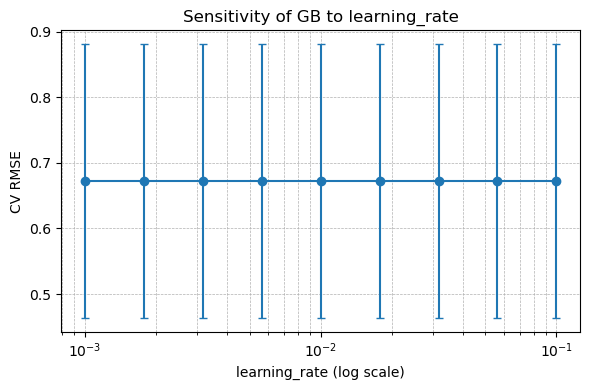

In [12]:
lr_vals = np.logspace(-3, -1, 9)    
cv = KFold(n_splits=5, shuffle=True, random_state=42)

mean_rmse, sd_rmse = [], []
for lr in lr_vals:
    mod = best_model.set_params(learning_rate=lr)
    
    scores = cross_val_score(mod, X_train, y_train,
                             scoring='neg_root_mean_squared_error',
                             cv=cv, n_jobs=-1)
    mean_rmse.append(-scores.mean())
    sd_rmse.append(scores.std())

# Sensitivity Analysis Plot
plt.figure(figsize=(6,4))
plt.errorbar(lr_vals, mean_rmse, yerr=sd_rmse, marker='o', capsize=3)
plt.xscale('log')
plt.xlabel('learning_rate (log scale)')
plt.ylabel('CV RMSE')
plt.title('Sensitivity of GB to learning_rate')
plt.grid(True, which='both', ls='--', lw=.5)
plt.tight_layout()

### Failure Analysis

In [13]:
y_pred = best_model.predict(X_test)
abs_err = np.abs(y_pred - y_test)

# ---- grab the three largest absolute errors ----
worst_idx = abs_err.argsort()[-3:][::-1]      # biggest → smallest
failure_df = (X_test.iloc[worst_idx]
              .assign(TrueVal=y_test[worst_idx],
                      Pred=y_pred[worst_idx],
                      AbsErr=abs_err[worst_idx])
              .reset_index(drop=True))
display(failure_df.T)

,0,1,2
x74r,0.797,-0.054,-1.118
term,-2.466,-1.710,0.560
ltv,-2.787,0.368,1.019
cltv,-2.798,0.355,1.005
dti,-0.150,-0.947,-0.867
...,...,...,...
cashout_1,False,True,False
cashout_2,True,False,True
TrueVal,2.797,-0.271,2.121
Pred,1.354,1.074,1.252
